<a href="https://colab.research.google.com/github/Optimus0205/Employee-Attrition/blob/main/Project_2_Employee_Attrition_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Employee Attrition Prediction**

Whether an employee is likely to leave the company based on factors like :
- job satisfaction,
- salary,
- work-life balance,
- years at the company,
- and performance ratings.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#**Task 1** — Data Loading & Exploration




##i- Load the CSV file using Pandas

In [ ]:
df=pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

##ii- Display the first 10 rows

In [ ]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,F,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,R&D,8,1,Life Sciences,3,M,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,R&D,2,2,Other,4,M,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,R&D,3,4,Life Sciences,4,F,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,R&D,2,1,Medical,1,M,...,3,4,1,6,3,3,2,2,2,2
5,32,0,Travel_Frequently,1005,R&D,2,2,Life Sciences,4,M,...,3,3,0,8,2,2,7,7,3,6
6,59,0,Travel_Rarely,1324,R&D,3,3,Medical,3,F,...,4,1,3,12,3,2,1,0,0,0
7,30,0,Travel_Rarely,1358,R&D,24,1,Life Sciences,4,M,...,4,2,1,1,2,3,1,0,0,0
8,38,0,Travel_Frequently,216,R&D,23,3,Life Sciences,4,M,...,4,2,0,10,2,3,9,7,1,8
9,36,0,Travel_Rarely,1299,R&D,27,3,Medical,3,M,...,3,2,2,17,3,2,7,7,7,7


##iii- Check how many rows and columns are there

In [ ]:
df.shape

(1470, 31)

##iv- Identify the target column (Attrition — Yes/No)

In [ ]:
# y-> target column
x=df.drop('Attrition', axis=1)
y=df['Attrition']

##v- Count how many employees left vs stayed and calculate the attrition rate as a percentage

In [ ]:
df_yes=df[df['Attrition']=='Yes']
df_yes['Attrition'].value_counts()

,count
Attrition,
Yes,237


In [ ]:
df_yes['Attrition'].count()

np.int64(237)

In [ ]:
(df_yes['Attrition'].count()/df['Attrition'].count())*100

np.float64(16.122448979591837)

In [ ]:
df_no=df[df['Attrition']=='No']
df_no['Attrition'].value_counts()

,count
Attrition,
No,1233


In [ ]:
(df_no['Attrition'].count()/df['Attrition'].count())*100

np.float64(83.87755102040816)

##vi- Identify how many columns are numeric vs categorical

In [ ]:
pd.DataFrame(df.dtypes, columns=['data_type']).groupby('data_type').value_counts()

,count
data_type,
int64,26
object,9


##vii- Write one observation: what do you notice about the attrition rate — is it balanced or imbalanced?


The attrition rate is fully imbalance and reflects that most of the employees are not leaving the firm but there are still ~16% people who may leave the job

# **Task 2** — Data Cleaning & Preprocessing



##i- Check for missing/null values and handle them

In [ ]:
df.info()
# No missing or null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

##ii- Drop columns that add no value to prediction (e.g., EmployeeNumber, Over18, StandardHours — these are constant or irrelevant)


In [ ]:
df=df.drop(columns=['EmployeeCount','EmployeeNumber','Over18','StandardHours'],axis=1)
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,F,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,R&D,8,1,Life Sciences,3,M,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,R&D,2,2,Other,4,M,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,R&D,3,4,Life Sciences,4,F,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,R&D,2,1,Medical,1,M,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,R&D,23,2,Medical,3,M,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,R&D,6,1,Medical,4,M,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,R&D,4,3,Life Sciences,2,M,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,M,...,3,4,0,17,3,2,9,6,0,8


##iii- Convert the target column Attrition from Yes/No to 1/0

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Attrition']=le.fit_transform(df['Attrition'])
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,F,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,R&D,8,1,Life Sciences,3,M,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,R&D,2,2,Other,4,M,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,R&D,3,4,Life Sciences,4,F,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,R&D,2,1,Medical,1,M,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,884,R&D,23,2,Medical,3,M,...,3,3,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,613,R&D,6,1,Medical,4,M,...,3,1,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,155,R&D,4,3,Life Sciences,2,M,...,4,2,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,4,M,...,3,4,0,17,3,2,9,6,0,8


##iv- Encode all remaining categorical columns using One-Hot Encoding (e.g., Department, JobRole, MaritalStatus, BusinessTravel)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()

categorical_columns=df.select_dtypes(include=['object']).columns
categorical_columns


encoded_df=pd.DataFrame(ohe.fit_transform(df[categorical_columns]).toarray(),columns=ohe.get_feature_names_out())
encoded_df

final_df=pd.concat([df.drop(categorical_columns,axis=1),encoded_df],axis=1)
final_df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,49,0,279,8,1,3,61,2,2,2,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,37,1,1373,2,2,4,92,2,1,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,33,0,1392,3,4,4,56,3,1,3,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,27,0,591,2,1,1,40,3,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,41,4,2,4,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1466,39,0,613,6,1,4,42,2,3,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1467,27,0,155,4,3,2,87,4,2,2,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1468,49,0,1023,2,3,4,63,2,2,2,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


##v- Scale numeric features using StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

y = final_df['Attrition']
features_df = final_df.drop('Attrition', axis=1)

scaler = StandardScaler()
x = pd.DataFrame(scaler.fit_transform(features_df), columns=features_df.columns)

x

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.534873,-0.918921,1.458650,-1.591746,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,-0.534873,1.088232,-0.685565,0.628241,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,-0.918921,1.458650,-1.591746,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,-0.534873,1.088232,-0.685565,-1.591746,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,1.088232,-0.685565,0.628241,-0.628241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,-0.101159,0.202082,1.703764,-0.891688,0.254625,-1.224807,1.785511,-0.057788,1.153254,-0.835451,...,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,1.088232,-0.685565,0.628241,-0.628241
1466,0.227347,-0.469754,-0.393938,-1.868426,1.169781,-1.175601,-1.026167,0.845911,-1.567907,0.741140,...,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,1.088232,-0.685565,0.628241,-0.628241
1467,-1.086676,-1.605183,-0.640727,0.085049,-0.660531,1.038693,1.785511,-0.057788,-0.660853,-0.076690,...,3.022901,-0.239904,-0.497873,-0.533821,-0.244625,-0.534873,1.088232,-0.685565,-1.591746,1.591746
1468,1.322365,0.546677,-0.887515,0.085049,1.169781,-0.142264,-1.026167,-0.057788,-0.660853,-0.236474,...,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.534873,1.088232,-0.685565,0.628241,-0.628241


#**Task 3** — Exploratory Data Analysis — EDA


##i- Attrition rate by Department — which department loses the most employees?


The most employees are losed in Sales-->HR-->R&D

In [ ]:
df_department_status=df['Department'].groupby(df['Attrition']).value_counts().reset_index(name='count')
df_department_status

,Attrition,Department,count
0,0,R&D,828
1,0,Sales,354
2,0,HR,51
3,1,R&D,133
4,1,Sales,92
5,1,HR,12


In [ ]:
department_attrition_rate = df_department_status.pivot(index='Department', columns='Attrition', values='count').reset_index()
department_attrition_rate.columns = ['Department', 'Stayed', 'Left']
department_attrition_rate['Total Employees'] = department_attrition_rate['Stayed'] + department_attrition_rate['Left']
department_attrition_rate['Attrition Rate (%)'] = (department_attrition_rate['Left'] / department_attrition_rate['Total Employees']) * 100
department_attrition_rate.sort_values(by='Attrition Rate (%)', ascending=False)

,Department,Stayed,Left,Total Employees,Attrition Rate (%)
2,Sales,354,92,446,20.627803
0,HR,51,12,63,19.047619
1,R&D,828,133,961,13.839750


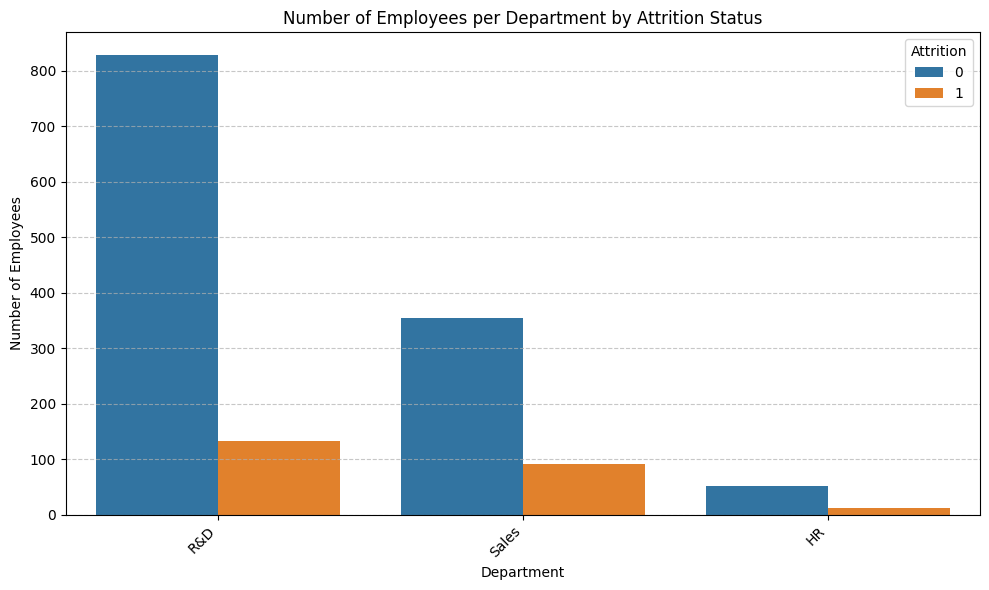

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(data=df_department_status, x='Department', y='count', hue='Attrition')

plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.title('Number of Employees per Department by Attrition Status')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# The most employees are losed in R&D-->Sales-->HR

##ii- Attrition rate by Job Role — which roles have the highest exit rate?


Sales Representative has the highest exit rate

In [ ]:
df_jobrole_status=df['JobRole'].groupby(df['Attrition']).value_counts().reset_index(name='count')
df_jobrole_status

,Attrition,JobRole,count
0,0,Sales Executive,269
1,0,Research Scientist,245
2,0,Laboratory Technician,197
3,0,Manufacturing Director,135
4,0,Healthcare Representative,122
5,0,Manager,97
6,0,Research Director,78
7,0,Sales Representative,50
8,0,Human Resources,40
9,1,Laboratory Technician,62


In [ ]:
job_role_attrition_rate=df_jobrole_status.pivot(index='JobRole',columns='Attrition',values='count').reset_index()
job_role_attrition_rate.columns=['JobRole','Stayed','Left']
job_role_attrition_rate['Total Employees']=job_role_attrition_rate['Stayed']+job_role_attrition_rate['Left']
job_role_attrition_rate['Attrition rate (%)']=(job_role_attrition_rate['Left']/job_role_attrition_rate['Total Employees'])*100
job_role_attrition_rate.sort_values(by='Attrition rate (%)', ascending=False)

,JobRole,Stayed,Left,Total Employees,Attrition rate (%)
8,Sales Representative,50,33,83,39.759036
2,Laboratory Technician,197,62,259,23.938224
1,Human Resources,40,12,52,23.076923
7,Sales Executive,269,57,326,17.484663
6,Research Scientist,245,47,292,16.095890
4,Manufacturing Director,135,10,145,6.896552
0,Healthcare Representative,122,9,131,6.870229
3,Manager,97,5,102,4.901961
5,Research Director,78,2,80,2.500000


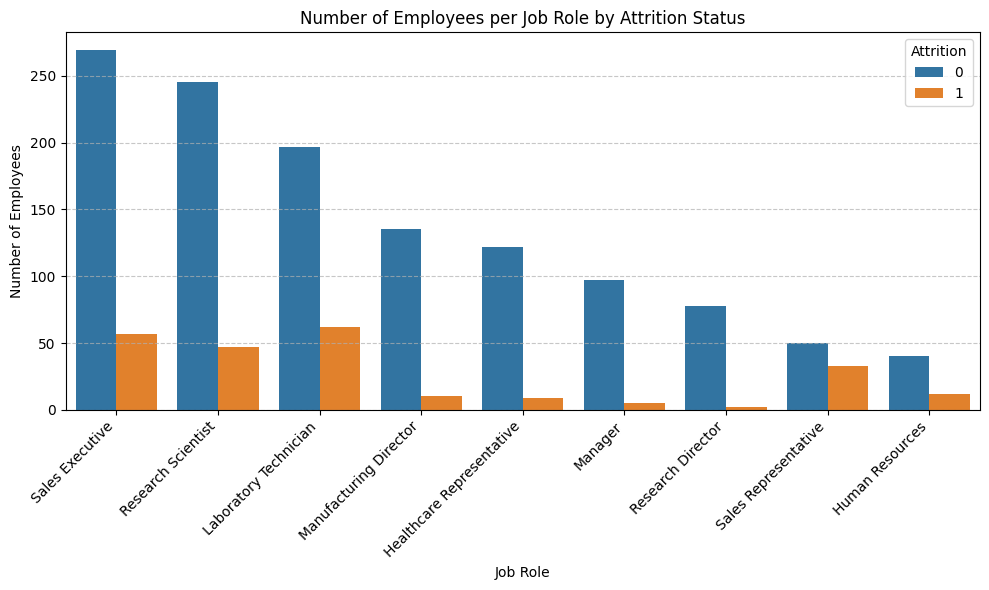

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(data=df_jobrole_status, x='JobRole', y='count', hue='Attrition')

plt.xlabel('Job Role')
plt.ylabel('Number of Employees')
plt.title('Number of Employees per Job Role by Attrition Status')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Laboratory Technician has the highest exit rate

##iii- Attrition vs Monthly Income — do lower paid employees leave more?

From the histplot we can say yes

In [ ]:
df_monthlyincome_status=df['MonthlyIncome'].groupby(df['Attrition']).value_counts().reset_index(name='count')
df_monthlyincome_status

,Attrition,MonthlyIncome,count
0,0,2342,3
1,0,2451,3
2,0,2559,3
3,0,3452,3
4,0,5562,3
...,...,...,...
1383,1,18824,1
1384,1,19246,1
1385,1,19545,1
1386,1,19845,1


<Axes: xlabel='MonthlyIncome', ylabel='Count'>

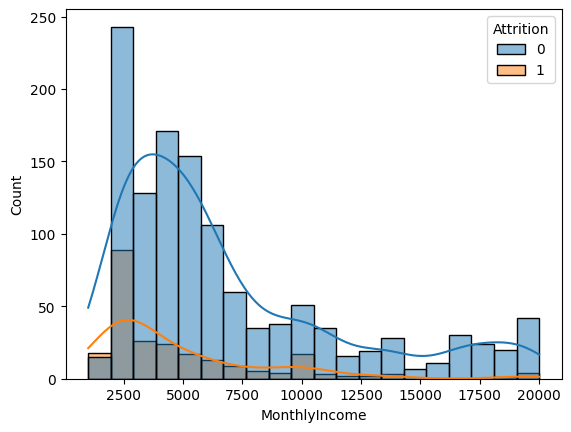

In [ ]:
sns.histplot(data=df, x='MonthlyIncome', hue='Attrition', kde=True)

##iv- Attrition vs Work-Life Balance rating — is there a visible pattern?

From the attrition rate we can say that who has found the least work balance(~1) may leave the company

In [ ]:
df_work_life_balance=df['Attrition'].groupby(df['WorkLifeBalance']).value_counts().reset_index(name='count')
df_work_life_balance

,WorkLifeBalance,Attrition,count
0,1,0,55
1,1,1,25
2,2,0,286
3,2,1,58
4,3,0,766
5,3,1,127
6,4,0,126
7,4,1,27


In [ ]:
work_life_balance_attrition_rate=df_work_life_balance.pivot(index='WorkLifeBalance',columns='Attrition',values='count').reset_index()
work_life_balance_attrition_rate.columns=['WorkLifeBalance','Stayed','Left']
work_life_balance_attrition_rate['Total Employees']=work_life_balance_attrition_rate['Stayed']+work_life_balance_attrition_rate['Left']
work_life_balance_attrition_rate['Attrition rate (%)']=(work_life_balance_attrition_rate['Left']/work_life_balance_attrition_rate['Total Employees'])*100
work_life_balance_attrition_rate.sort_values(by='Attrition rate (%)', ascending=False)

,WorkLifeBalance,Stayed,Left,Total Employees,Attrition rate (%)
0,1,55,25,80,31.250000
3,4,126,27,153,17.647059
1,2,286,58,344,16.860465
2,3,766,127,893,14.221725


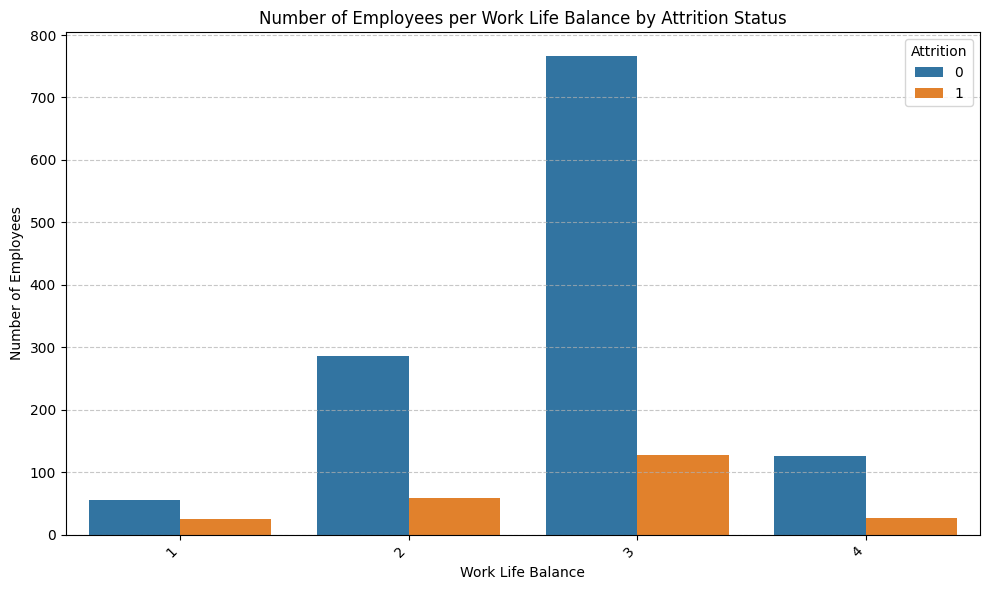

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(data=df_work_life_balance, x='WorkLifeBalance',y='count', hue='Attrition')

plt.xlabel('Work Life Balance')
plt.ylabel('Number of Employees')
plt.title('Number of Employees per Work Life Balance by Attrition Status')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Axes: xlabel='WorkLifeBalance', ylabel='Count'>

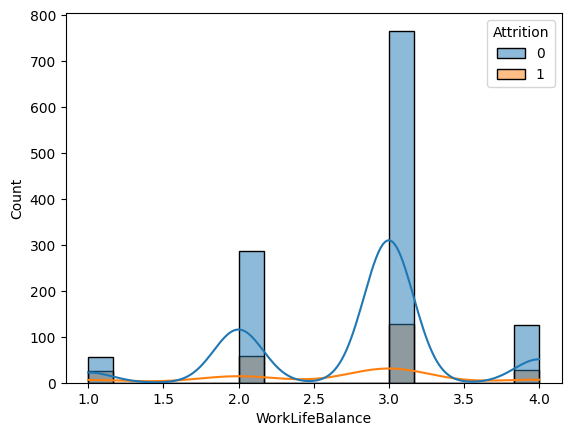

In [ ]:
sns.histplot(data=df, x='WorkLifeBalance', hue='Attrition', kde=True)

##v- Attrition vs Years at Company — at what point in tenure do employees leave most?

The people leaves the company most within the 1st year and after that there are almost  20-25 employees leaving between 1-5 years and after that there is again a peak at 10th year(~20 employees left) after that it is almost 0

In [ ]:
df_years_at_company=df['YearsAtCompany'].groupby(df['Attrition']).value_counts().reset_index(name='count')
df_years_at_company

,Attrition,YearsAtCompany,count
0,0,5,175
1,0,1,112
2,0,3,108
3,0,10,102
4,0,2,100
...,...,...,...
59,1,24,1
60,1,31,1
61,1,32,1
62,1,33,1


<Axes: xlabel='YearsAtCompany', ylabel='Count'>

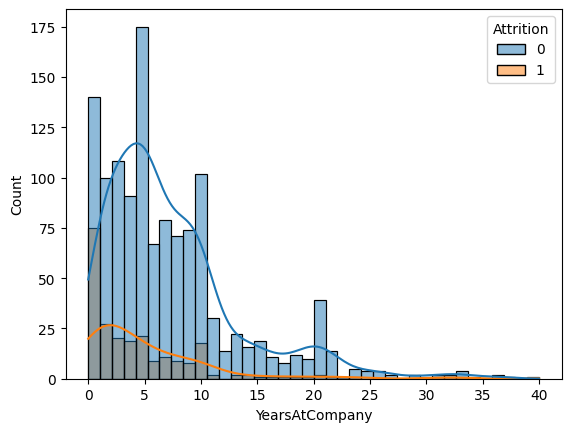

In [ ]:
sns.histplot(data=df,x='YearsAtCompany',hue='Attrition',kde=True)

##vi- Write 4–5 specific business insights from your EDA (not generic — specific numbers and patterns from the data)

### **Business Insights from EDA:**

1. The Sales department has the highest attrition rate of 20.63% followed by Human Resources at 19.05%. This suggests that these departments may require specific attention in retention strategies, despite R&D having a larger absolute number of left (133) due to its size.
2.  Sales Representatives have an alarmingly high exit rate of nearly 40% (33 out of 83 employees), making this role the most susceptible to attrition.  Laboratory Technicians (23.94%) and Human Resources (23.08%) also have significantly high attrition rates, suggesting possible issues specific to these job functions.
3.  There is a trend that employees with a lower monthly salary are more likely to leave. The distribution of Monthly Income for those who left, skews towards the lower end compared to those who stayed, suggesting that competitive compensation is a critical factor in retention.
4.  Poor Work-Life Balance is a strong predictor for attrition. The attrition rate was highest for employees who rated 1 (lowest) for their Work-Life Balance at 31.25%, which is more than twice the rate of employees who rated 3 (balanced) at 14.22%.
5.   The highest employee attrition occurs in the first year of employment at the company, with a significant number of employees leaving. Attrition persists in subsequent years, but the first year is especially important, indicating a possible gap in onboarding, integration, or early career development.

# **Task 4** — Model Building & Comparison


##i-Split data into training and test sets (80/20)


In [ ]:
y = final_df['Attrition']
features_df = final_df.drop('Attrition', axis=1)

scaler = StandardScaler()
x = pd.DataFrame(scaler.fit_transform(features_df), columns=features_df.columns)

x.shape, y.shape

((1470, 51), (1470,))

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((1176, 51), (294, 51), (1176,), (294,))

##ii-Handle class imbalance using class_weight='balanced' parameter (a simpler approach than SMOTE — good to know both exist)

##iii-Train the following 3 models:

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

###i-Logistic Regression (baseline — also the most explainable to HR teams)

In [ ]:
logr=LogisticRegression(class_weight='balanced',random_state=42)
logr.fit(x_train,y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [ ]:
y_pred_log=logr.predict(x_test)

###ii-Random Forest Classifier

In [ ]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred_rf = rf.predict(x_test)

###iii-Gradient Boosting Classifier

In [ ]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(x_train, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
y_pred_gb = gb.predict(x_test)

##iv-Record all results in a comparison table inside your notebook

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

# Extract metrics for Logistic Regression
log_accuracy = accuracy_score(y_test, y_pred_log)
log_report = classification_report(y_test, y_pred_log, output_dict=True)
log_precision = log_report['1']['precision']
log_recall = log_report['1']['recall']
log_f1 = log_report['1']['f1-score']
log_roc_auc = roc_auc_score(y_test, logr.predict_proba(x_test)[:, 1])

# Extract metrics for Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)
rf_precision = rf_report['1']['precision']
rf_recall = rf_report['1']['recall']
rf_f1 = rf_report['1']['f1-score']
rf_roc_auc = roc_auc_score(y_test, rf.predict_proba(x_test)[:, 1])

# Extract metrics for Gradient Boosting
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_report = classification_report(y_test, y_pred_gb, output_dict=True)
gb_precision = gb_report['1']['precision']
gb_recall = gb_report['1']['recall']
gb_f1 = gb_report['1']['f1-score']
gb_roc_auc = roc_auc_score(y_test, gb.predict_proba(x_test)[:, 1])

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [log_accuracy, rf_accuracy, gb_accuracy],
    'Precision (Class 1)': [log_precision, rf_precision, gb_precision],
    'Recall (Class 1)': [log_recall, rf_recall, gb_recall],
    'F1-Score (Class 1)': [log_f1, rf_f1, gb_f1],
    'ROC-AUC': [log_roc_auc, rf_roc_auc, gb_roc_auc]
})

print(comparison_df.round(3))

                 Model  Accuracy  Precision (Class 1)  Recall (Class 1)  \
0  Logistic Regression     0.718                0.256             0.590   
1        Random Forest     0.871                0.600             0.077   
2    Gradient Boosting     0.878                0.600             0.231   

   F1-Score (Class 1)  ROC-AUC  
0               0.357    0.766  
1               0.136    0.714  
2               0.333    0.797  


#**Task 5** — Model Evaluation

##i-Evaluate all 3 models using:


###i Precision, Recall, F1-Score


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

Logistic Regression

In [ ]:
log_precision=precision_score(y_test,y_pred_log)
log_recall=recall_score(y_test,y_pred_log)
log_f1score=f1_score(y_test,y_pred_log)

print('Logistion Regression Precision :',log_precision)
print('Logistion Regression Recall :',log_recall)
print('Logistion Regression F1-Score :',log_f1score)

Logistion Regression Precision : 0.25555555555555554
Logistion Regression Recall : 0.5897435897435898
Logistion Regression F1-Score : 0.35658914728682173


Random Forest

In [ ]:
rf_precision=precision_score(y_test,y_pred_rf)
rf_recall=recall_score(y_test,y_pred_rf)
rf_f1score=f1_score(y_test,y_pred_rf)

print('Random Forest Precision :',rf_precision)
print('Random Forest Recall :',rf_recall)
print('Random Forest F1-Score :',rf_f1score)

Random Forest Precision : 0.6
Random Forest Recall : 0.07692307692307693
Random Forest F1-Score : 0.13636363636363635


Gradient Boosting

In [ ]:
gb_precision=precision_score(y_test,y_pred_gb)
gb_recall=recall_score(y_test,y_pred_gb)
gb_f1score=f1_score(y_test,y_pred_gb)

print('Gradient Boosting Precision :',gb_precision)
print('Gradient Boosting Recall :',gb_recall)
print('Gradient Boosting F1-Score :',gb_f1score)

Gradient Boosting Precision : 0.6
Gradient Boosting Recall : 0.23076923076923078
Gradient Boosting F1-Score : 0.3333333333333333


###ii ROC-AUC Score

In [ ]:
from sklearn.metrics import roc_auc_score

In [ ]:
# Logistic Regression
log_roc_auc=roc_auc_score(y_test,logr.predict_proba(x_test)[:,1])
print('Logistic Regression ROC-AUC Score :',log_roc_auc)

# Random forest
rf_roc_auc=roc_auc_score(y_test,rf.predict_proba(x_test)[:,1])
print('Random Forest ROC-AUC Score :',rf_roc_auc)

# Gradient Boosting
gb_roc_auc=roc_auc_score(y_test,gb.predict_proba(x_test)[:,1])
print('Gradient Boosting ROC-AUC Score :',gb_roc_auc)

Logistic Regression ROC-AUC Score : 0.7658119658119658
Random Forest ROC-AUC Score : 0.7136752136752137
Gradient Boosting ROC-AUC Score : 0.7965811965811966



###iii Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
# Logistic Regression
log_confusion_matrix=confusion_matrix(y_test,y_pred_log)
print(log_confusion_matrix)

[[188  67]
 [ 16  23]]


In [ ]:
# Random forest
rf_confusion_matrix=confusion_matrix(y_test,y_pred_rf)
print(rf_confusion_matrix)

[[253   2]
 [ 36   3]]


In [ ]:
# Gradient Boosting
gb_confusion_matrix=confusion_matrix(y_test,y_pred_gb)
print(gb_confusion_matrix)

[[249   6]
 [ 30   9]]


##ii-Identify and clearly state which model performed best and why


We can say that Gradient boosting is performing well as it has best roc-auc, accuracy and precision score But Logistic Regression is also performing well.

##iii-For the best model: extract Feature Importance — which factors matter most in predicting attrition?

Monthly income


##iv-Rank the top 10 most important features driving employee exit

In [ ]:
importances = gb.feature_importances_

feature_importance_df = (
    pd.DataFrame({'Feature': x_train.columns, 'Importance': importances})
    .sort_values('Importance', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
feature_importance_df.index += 1

print(f"Top 10 Features Driving Attrition (Gradient Boosting):")
feature_importance_df

Top 10 Features Driving Attrition (Gradient Boosting):


,Feature,Importance
1,MonthlyIncome,0.126804
2,OverTime_Yes,0.098821
3,Age,0.058898
4,JobLevel,0.049674
5,DistanceFromHome,0.045516
6,JobInvolvement,0.043667
7,DailyRate,0.043573
8,StockOptionLevel,0.041210
9,TotalWorkingYears,0.038640
10,YearsAtCompany,0.035397


#**Task 6** — Visualization (Minimum 4 charts)

##i-Chart 1: Bar chart showing attrition rate by Department and Job Role

/tmp/ipykernel_14071/2878894515.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=department_attrition_rate.sort_values(by='Attrition Rate (%)', ascending=False), x='Department', y='Attrition Rate (%)', palette='colorblind')


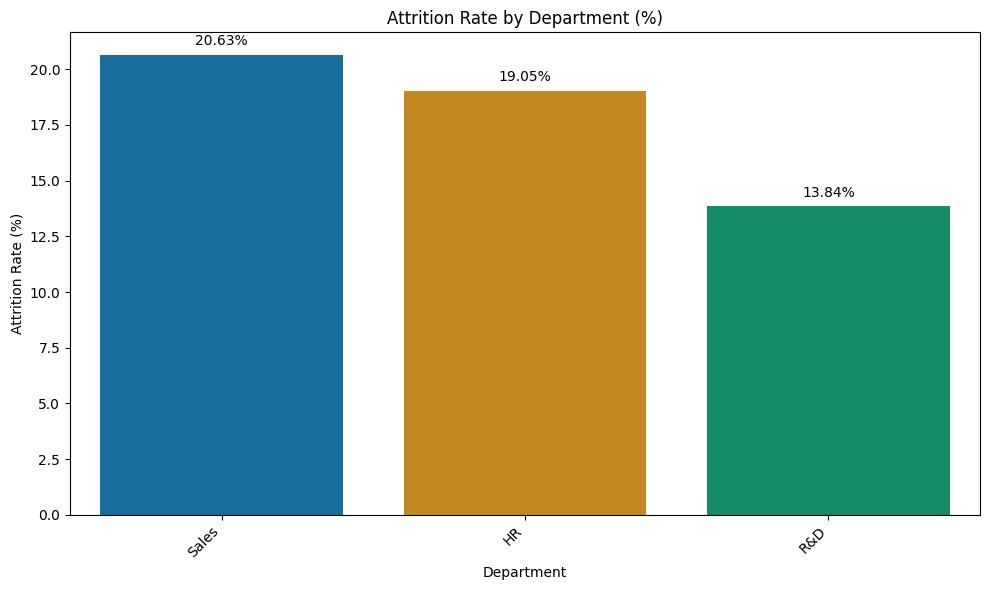

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=department_attrition_rate.sort_values(by='Attrition Rate (%)', ascending=False), x='Department', y='Attrition Rate (%)', palette='colorblind')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.title('Attrition Rate by Department (%)')
plt.xticks(rotation=45, ha='right')

# Add percentage labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

/tmp/ipykernel_14071/2717294782.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=job_role_attrition_rate.sort_values(by='Attrition rate (%)', ascending=False), x='JobRole', y='Attrition rate (%)',palette='colorblind')


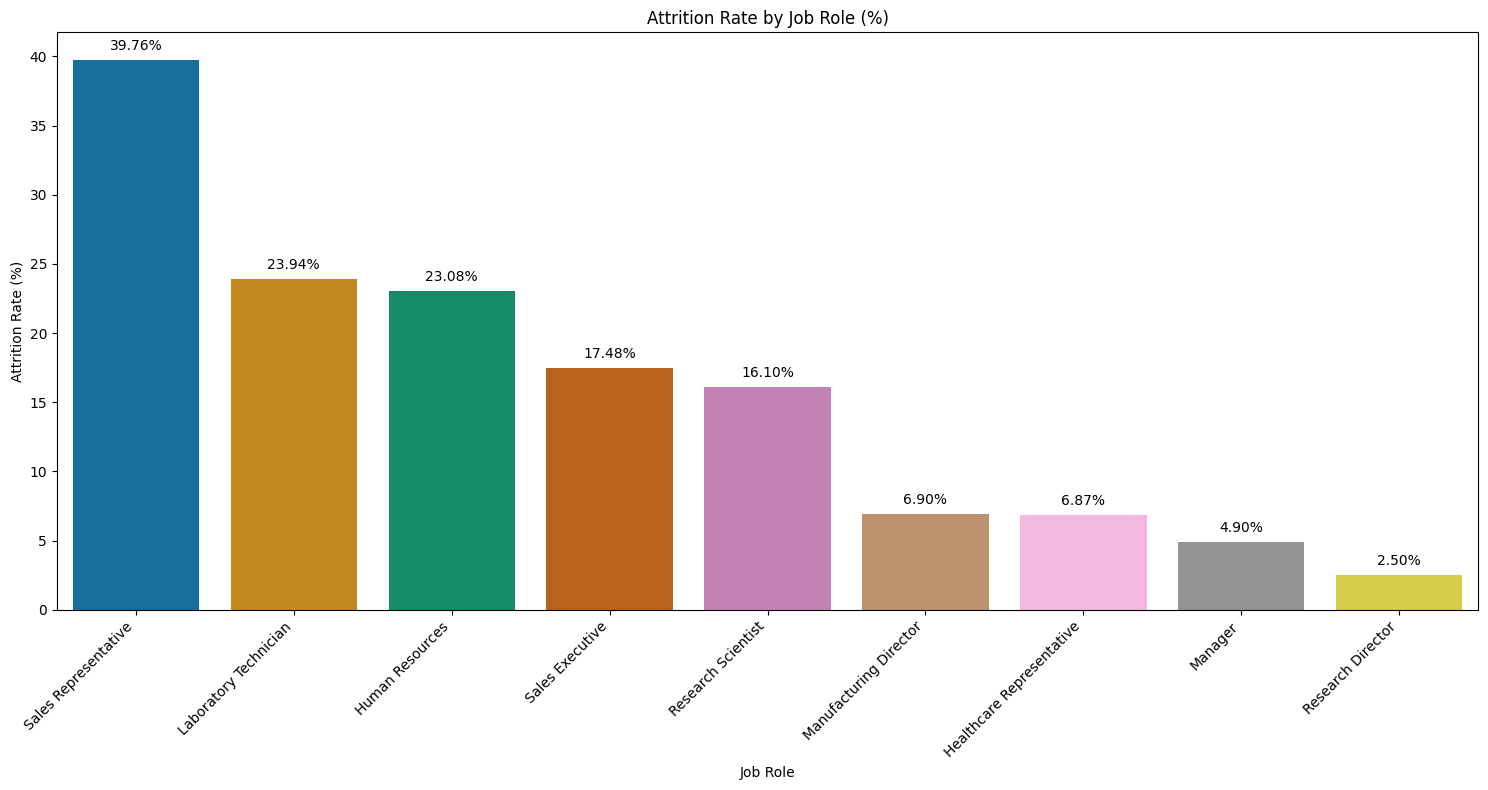

In [ ]:
plt.figure(figsize=(15, 8))
ax = sns.barplot(data=job_role_attrition_rate.sort_values(by='Attrition rate (%)', ascending=False), x='JobRole', y='Attrition rate (%)',palette='colorblind')
plt.xlabel('Job Role')
plt.ylabel('Attrition Rate (%)')
plt.title('Attrition Rate by Job Role (%)')
plt.xticks(rotation=45, ha='right')

# Add percentage labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

##ii-Chart 2: Box plot comparing Monthly Income of employees who left vs stayed

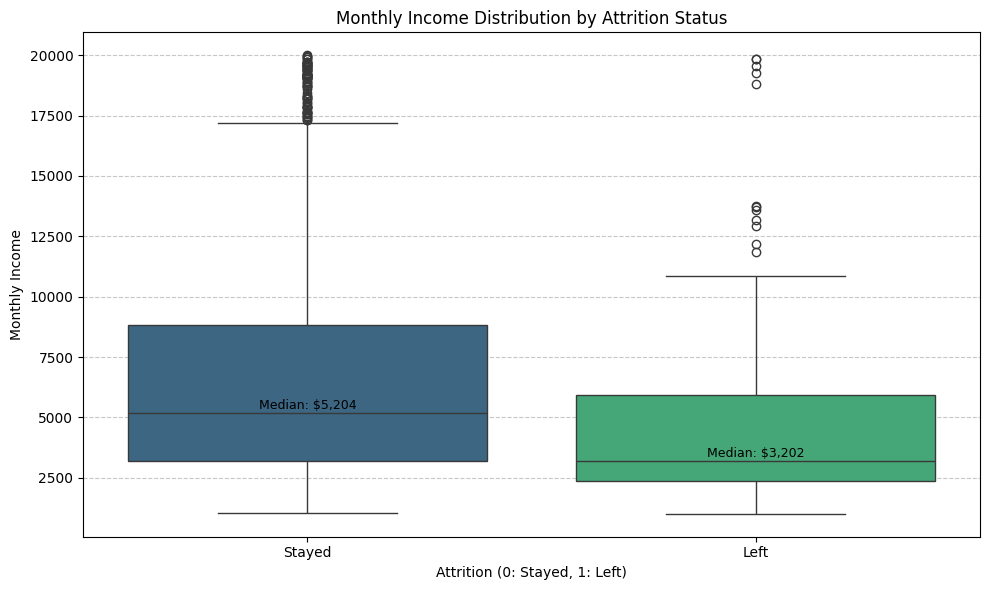

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition', palette='viridis', legend=False)
plt.title('Monthly Income Distribution by Attrition Status')
plt.xlabel('Attrition (0: Stayed, 1: Left)')
plt.ylabel('Monthly Income')
plt.xticks([0, 1], ['Stayed', 'Left'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Define stayed_income and left_income from the DataFrame
stayed = df[df['Attrition'] == 0]['MonthlyIncome']
left = df[df['Attrition'] == 1]['MonthlyIncome']

for p, data in enumerate([stayed, left], 0):
    ax.text(p, data.median() + 150, f"Median: ${data.median():,.0f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

##iii-Chart 3: Confusion Matrix heatmap for your best model

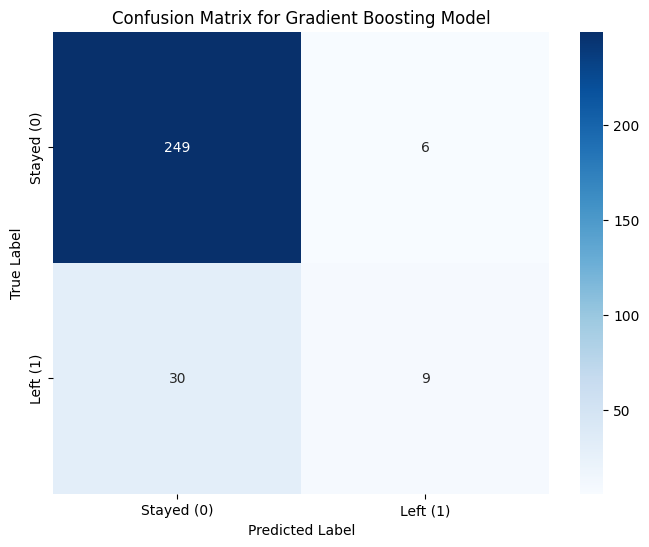

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get the confusion matrix for the Gradient Boosting model
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed (0)', 'Left (1)'],
            yticklabels=['Stayed (0)', 'Left (1)'])
plt.title('Confusion Matrix for Gradient Boosting Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

##iv-Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model

/tmp/ipykernel_14071/864642192.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


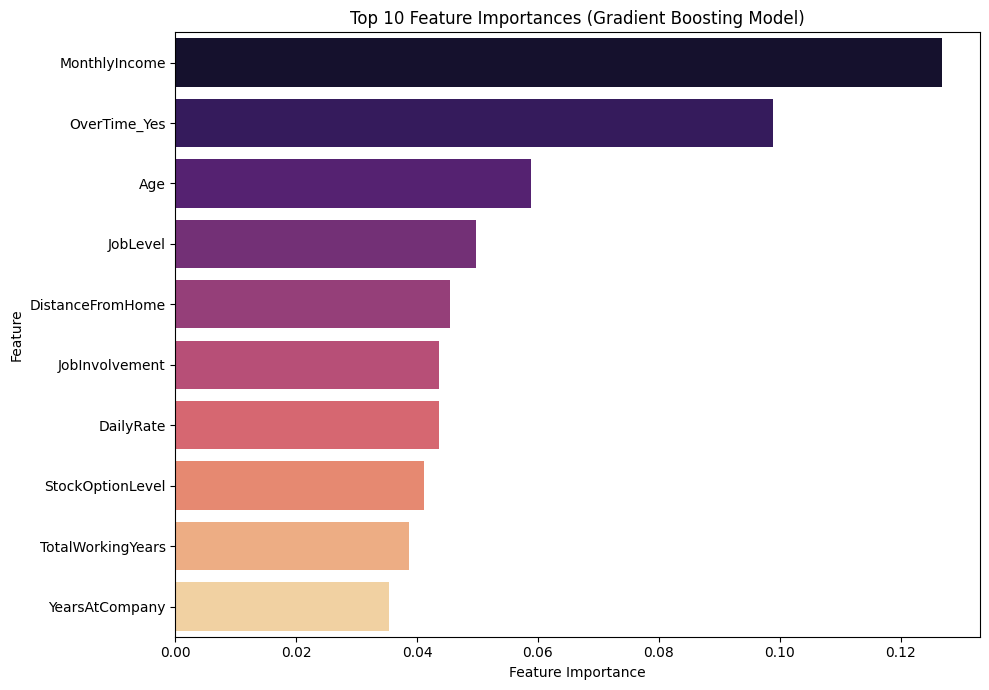

In [ ]:
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Top 10 Feature Importances (Gradient Boosting Model)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

##v-Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph

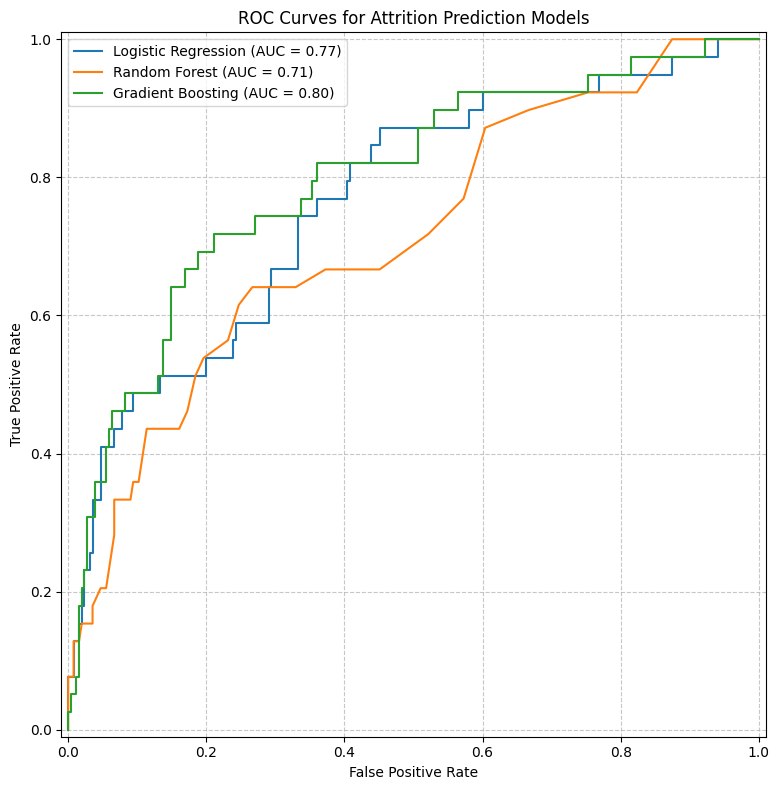

In [ ]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(10, 8))

# Plot ROC curve for Logistic Regression
RocCurveDisplay.from_estimator(logr, x_test, y_test, name='Logistic Regression', ax=plt.gca())

# Plot ROC curve for Random Forest
RocCurveDisplay.from_estimator(rf, x_test, y_test, name='Random Forest', ax=plt.gca())

# Plot ROC curve for Gradient Boosting
RocCurveDisplay.from_estimator(gb, x_test, y_test, name='Gradient Boosting', ax=plt.gca())

plt.title('ROC Curves for Attrition Prediction Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

#**Task 7** — HR Insights & Business Recommendations




##Write a short paragraph (6–10 lines) inside your notebook answering:
###i-Which 3 factors most strongly predict that an employee will leave?
###ii-Which department or job role should HR prioritize for retention efforts?
###iii-Does salary alone explain attrition or are there other stronger factors?
###iv-Write 2 concrete HR recommendations a company could implement based on your findings (e.g., specific policy changes, who to target for a retention conversation)
###v-What limitation does this model have that an HR team should be aware of before using it?

The three strongest predictors of employee attrition are **Monthly Income**, **OverTime (Yes)**, and **Age**. HR should prioritize retention efforts in the **Sales department**, particularly targeting **Sales Representatives** due to their high exit rate (nearly 40%), followed by Laboratory Technicians and Human Resources roles. While **salary (Monthly Income)** is the most significant factor, attrition is not solely explained by it; other strong factors like OverTime_Yes, Age, and JobLevel also play crucial roles. Based on these findings, two concrete HR recommendations are: 1) **Review compensation and overtime policies** for high-risk roles to ensure competitive salaries and mitigate burnout, and 2) **Implement targeted support programs** for early-career employees and those in Sales and HR departments, focusing on mentorship and work-life balance. A key limitation of the predictive model is its low **Recall (Class 1) of 0.231**, meaning it only identifies a small fraction of actual leavers, and HR teams should be aware that it will miss many potential attritions.